In [1]:
# ================================================
# Cookie Cats A/B Test Analysis
# ================================================
# Business Question:
# Should we move the first gate from level 30 to level 40?
# Does it significantly change Day-1 and Day-7 player retention?
#
# Dataset: ~90,000 players
# Control:   gate_30 (old design)
# Treatment: gate_40 (new design)
# ================================================

In [2]:
#Cell 2 — Load all libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
#Cell 3 — Load the data:
df = pd.read_csv('../data/cookie_cats.csv')

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Data loaded successfully!
Shape: (90189, 5)
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
# ================================================
# STEP 2: Exploratory Data Analysis
# ================================================

print("=== BASIC DATASET INFO ===")
print(f"Total players: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

=== BASIC DATASET INFO ===
Total players: 90,189
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']

Data types:
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Missing values:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


In [5]:
#Cell 5 — Group sizes
print("=== GROUP SIZES ===")
group_counts = df['version'].value_counts()
print(group_counts)
print(f"\nPercentage split:")
print(df['version'].value_counts(normalize=True).mul(100).round(2))

=== GROUP SIZES ===
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Percentage split:
version
gate_40    50.44
gate_30    49.56
Name: proportion, dtype: float64


In [6]:
#Cell 6 — Game rounds analysis
print("=== GAME ROUNDS ANALYSIS ===")
print(f"Average rounds played: {df['sum_gamerounds'].mean():.1f}")
print(f"Median rounds played: {df['sum_gamerounds'].median():.1f}")
print(f"Max rounds played: {df['sum_gamerounds'].max():,}")
print(f"Min rounds played: {df['sum_gamerounds'].min()}")
print(f"\nPlayers who played 0 rounds: {(df['sum_gamerounds'] == 0).sum():,}")
print(f"Players who played 1-10 rounds: {((df['sum_gamerounds'] >= 1) & (df['sum_gamerounds'] <= 10)).sum():,}")
print(f"Players who played 100+ rounds: {(df['sum_gamerounds'] >= 100).sum():,}")

=== GAME ROUNDS ANALYSIS ===
Average rounds played: 51.9
Median rounds played: 16.0
Max rounds played: 49,854
Min rounds played: 0

Players who played 0 rounds: 3,994
Players who played 1-10 rounds: 31,995
Players who played 100+ rounds: 12,516


In [7]:
#Cell 7 — Retention rates
print("=== RETENTION RATES BY GROUP ===")

retention = df.groupby('version')[['retention_1', 'retention_7']].mean().mul(100).round(2)
print(retention)

print(f"\n--- Plain English Summary ---")
print(f"Day-1 Retention:")
print(f"  gate_30: {retention.loc['gate_30', 'retention_1']}% of players came back the next day")
print(f"  gate_40: {retention.loc['gate_40', 'retention_1']}% of players came back the next day")

print(f"\nDay-7 Retention:")
print(f"  gate_30: {retention.loc['gate_30', 'retention_7']}% of players came back after 7 days")
print(f"  gate_40: {retention.loc['gate_40', 'retention_7']}% of players came back after 7 days")

=== RETENTION RATES BY GROUP ===
         retention_1  retention_7
version                          
gate_30        44.82        19.02
gate_40        44.23        18.20

--- Plain English Summary ---
Day-1 Retention:
  gate_30: 44.82% of players came back the next day
  gate_40: 44.23% of players came back the next day

Day-7 Retention:
  gate_30: 19.02% of players came back after 7 days
  gate_40: 18.2% of players came back after 7 days


In [8]:
# ================================================
# STEP 3: Experiment Validation
# ================================================

print("=== CHECK 1: SAMPLE RATIO MISMATCH (SRM) ===")

# Count players in each group
n_gate30 = len(df[df['version'] == 'gate_30'])
n_gate40 = len(df[df['version'] == 'gate_40'])
total = len(df)

print(f"gate_30 players: {n_gate30:,}")
print(f"gate_40 players: {n_gate40:,}")
print(f"Total players:   {total:,}")
print(f"Expected per group (50/50): {total//2:,}")
print(f"Difference from expected: {abs(n_gate30 - n_gate40):,} players")

# Calculate the ratio
ratio = n_gate40 / n_gate30
print(f"\nRatio (gate_40/gate_30): {ratio:.4f}")
print(f"Perfect ratio would be: 1.0000")
print(f"Difference from perfect: {abs(1 - ratio):.4f}")

if abs(1 - ratio) < 0.01:
    print("\n✅ No Sample Ratio Mismatch — groups are balanced")
else:
    print("\n❌ WARNING: Sample Ratio Mismatch detected!")

=== CHECK 1: SAMPLE RATIO MISMATCH (SRM) ===
gate_30 players: 44,700
gate_40 players: 45,489
Total players:   90,189
Expected per group (50/50): 45,094
Difference from expected: 789 players

Ratio (gate_40/gate_30): 1.0177
Perfect ratio would be: 1.0000
Difference from perfect: 0.0177

❌ WARNING: Sample Ratio Mismatch detected!


In [9]:
print("=== CHECK 2: ZERO ROUND PLAYERS ===")

# Find players who never played
zero_players = df[df['sum_gamerounds'] == 0]
zero_gate30 = len(zero_players[zero_players['version'] == 'gate_30'])
zero_gate40 = len(zero_players[zero_players['version'] == 'gate_40'])

print(f"Total players who played 0 rounds: {len(zero_players):,}")
print(f"  gate_30: {zero_gate30:,} ({zero_gate30/n_gate30*100:.2f}% of gate_30)")
print(f"  gate_40: {zero_gate40:,} ({zero_gate40/n_gate40*100:.2f}% of gate_40)")

print(f"\nRetention of 0-round players:")
print(zero_players[['retention_1', 'retention_7']].mean().mul(100).round(2))

print(f"\nShould we remove them?")
print(f"These players never saw the gate — including them adds noise to our analysis")

=== CHECK 2: ZERO ROUND PLAYERS ===
Total players who played 0 rounds: 3,994
  gate_30: 1,937 (4.33% of gate_30)
  gate_40: 2,057 (4.52% of gate_40)

Retention of 0-round players:
retention_1    2.18
retention_7    0.73
dtype: float64

Should we remove them?
These players never saw the gate — including them adds noise to our analysis


In [10]:
print("=== CHECK 3: OUTLIER CHECK ===")

print(f"Game rounds distribution:")
print(df['sum_gamerounds'].describe().round(2))

# Check extreme players
print(f"\nPlayers with 1000+ rounds: {(df['sum_gamerounds'] >= 1000).sum():,}")
print(f"Players with 2000+ rounds: {(df['sum_gamerounds'] >= 2000).sum():,}")
print(f"Players with 5000+ rounds: {(df['sum_gamerounds'] >= 5000).sum():,}")

# Are outliers evenly distributed between groups?
outliers_gate30 = len(df[(df['version'] == 'gate_30') & (df['sum_gamerounds'] >= 1000)])
outliers_gate40 = len(df[(df['version'] == 'gate_40') & (df['sum_gamerounds'] >= 1000)])

print(f"\n1000+ round players by group:")
print(f"  gate_30: {outliers_gate30:,}")
print(f"  gate_40: {outliers_gate40:,}")

=== CHECK 3: OUTLIER CHECK ===
Game rounds distribution:
count    90189.00
mean        51.87
std        195.05
min          0.00
25%          5.00
50%         16.00
75%         51.00
max      49854.00
Name: sum_gamerounds, dtype: float64

Players with 1000+ rounds: 118
Players with 2000+ rounds: 10
Players with 5000+ rounds: 1

1000+ round players by group:
  gate_30: 53
  gate_40: 65


In [11]:
# ================================================
# CREATING CLEANED DATASET
# ================================================

# Remove players who played 0 rounds
# Reason: they never reached the gate we're testing
# so their behavior tells us nothing about the gate's effect

df_clean = df[df['sum_gamerounds'] > 0].copy()

# .copy() creates a brand new independent copy of the filtered data
# Without .copy(), changes to df_clean might accidentally affect df
# Think of it like photocopying a document vs editing the original

print(f"Original dataset:  {len(df):,} players")
print(f"Cleaned dataset:   {len(df_clean):,} players")
print(f"Players removed:   {len(df) - len(df_clean):,} players")
print(f"\nCleaned group sizes:")
print(df_clean['version'].value_counts())
print(f"\nCleaned retention rates:")
retention_clean = df_clean.groupby('version')[['retention_1','retention_7']].mean().mul(100).round(2)
print(retention_clean)

Original dataset:  90,189 players
Cleaned dataset:   86,195 players
Players removed:   3,994 players

Cleaned group sizes:
version
gate_40    43432
gate_30    42763
Name: count, dtype: int64

Cleaned retention rates:
         retention_1  retention_7
version                          
gate_30        46.75        19.84
gate_40        46.22        19.03


In [12]:
# ================================================
# STEP 4: Hypothesis Formulation
# ================================================

print("=" * 55)
print("HYPOTHESIS FORMULATION")
print("=" * 55)

print("""
METRIC 1: Day-1 Retention
--------------------------
H0 (Null Hypothesis):
Moving the gate from level 30 to level 40 has NO effect 
on Day-1 retention. Any observed difference is due to 
random chance.

H1 (Alternative Hypothesis):
Moving the gate from level 30 to level 40 DOES have a 
real effect on Day-1 retention.

METRIC 2: Day-7 Retention
--------------------------
H0 (Null Hypothesis):
Moving the gate from level 30 to level 40 has NO effect 
on Day-7 retention. Any observed difference is due to 
random chance.

H1 (Alternative Hypothesis):
Moving the gate from level 30 to level 40 DOES have a 
real effect on Day-7 retention.

SIGNIFICANCE LEVEL
------------------
Alpha (α) = 0.05
Meaning: We need 95% confidence that the difference 
is real before rejecting the null hypothesis.

TEST TYPE: Two-tailed test
Meaning: We are checking for ANY difference 
(better OR worse) - not just improvement.
""")

print("=" * 55)
print(f"Day-1 Retention:")
print(f"  gate_30: {retention_clean.loc['gate_30', 'retention_1']}%")
print(f"  gate_40: {retention_clean.loc['gate_40', 'retention_1']}%")
print(f"  Observed difference: {retention_clean.loc['gate_30', 'retention_1'] - retention_clean.loc['gate_40', 'retention_1']:.2f}%")
print(f"\nDay-7 Retention:")
print(f"  gate_30: {retention_clean.loc['gate_30', 'retention_7']}%")
print(f"  gate_40: {retention_clean.loc['gate_40', 'retention_7']}%")
print(f"  Observed difference: {retention_clean.loc['gate_30', 'retention_7'] - retention_clean.loc['gate_40', 'retention_7']:.2f}%")
print("=" * 55)

HYPOTHESIS FORMULATION

METRIC 1: Day-1 Retention
--------------------------
H0 (Null Hypothesis):
Moving the gate from level 30 to level 40 has NO effect 
on Day-1 retention. Any observed difference is due to 
random chance.

H1 (Alternative Hypothesis):
Moving the gate from level 30 to level 40 DOES have a 
real effect on Day-1 retention.

METRIC 2: Day-7 Retention
--------------------------
H0 (Null Hypothesis):
Moving the gate from level 30 to level 40 has NO effect 
on Day-7 retention. Any observed difference is due to 
random chance.

H1 (Alternative Hypothesis):
Moving the gate from level 30 to level 40 DOES have a 
real effect on Day-7 retention.

SIGNIFICANCE LEVEL
------------------
Alpha (α) = 0.05
Meaning: We need 95% confidence that the difference 
is real before rejecting the null hypothesis.

TEST TYPE: Two-tailed test
Meaning: We are checking for ANY difference 
(better OR worse) - not just improvement.

Day-1 Retention:
  gate_30: 46.75%
  gate_40: 46.22%
  Observed di

In [13]:
# ================================================
# STEP 5: Selecting the Statistical Test
# ================================================

print("=" * 55)
print("STATISTICAL TEST SELECTION")
print("=" * 55)

print("""
DATA TYPE CHECK:
----------------
retention_1 and retention_7 are binary (True/False)
This means we are comparing two PROPORTIONS
→ Correct test: Z-test for proportions

SAMPLE SIZE CHECK:
------------------""")

# Check sample sizes for each group
n1 = len(df_clean[df_clean['version'] == 'gate_30'])
n2 = len(df_clean[df_clean['version'] == 'gate_40'])

print(f"gate_30 sample size: {n1:,}")
print(f"gate_40 sample size: {n2:,}")
print(f"Minimum required:    30")
print(f"Our samples are large enough: ✅")

print("""
ASSUMPTIONS CHECK:
------------------
1. Data is binary (True/False)          ✅
2. Two independent groups               ✅
3. Large enough sample size             ✅
4. Players randomly assigned to groups  ✅

CONCLUSION:
-----------
We will use the Z-test for proportions
from scipy.stats (proportions_ztest)

This test will tell us:
- Z-statistic: how many standard deviations 
  our difference is from zero
- P-value: probability that this difference 
  happened by random chance
""")

print("=" * 55)

STATISTICAL TEST SELECTION

DATA TYPE CHECK:
----------------
retention_1 and retention_7 are binary (True/False)
This means we are comparing two PROPORTIONS
→ Correct test: Z-test for proportions

SAMPLE SIZE CHECK:
------------------
gate_30 sample size: 42,763
gate_40 sample size: 43,432
Minimum required:    30
Our samples are large enough: ✅

ASSUMPTIONS CHECK:
------------------
1. Data is binary (True/False)          ✅
2. Two independent groups               ✅
3. Large enough sample size             ✅
4. Players randomly assigned to groups  ✅

CONCLUSION:
-----------
We will use the Z-test for proportions
from scipy.stats (proportions_ztest)

This test will tell us:
- Z-statistic: how many standard deviations 
  our difference is from zero
- P-value: probability that this difference 
  happened by random chance



In [14]:
# ================================================
# STEP 6: Running the Statistical Test
# ================================================
from statsmodels.stats.proportion import proportions_ztest

# ---- Prepare the numbers ----

# Count of players who came back (True = 1, so sum counts Trues)
gate_30 = df_clean[df_clean['version'] == 'gate_30']
gate_40 = df_clean[df_clean['version'] == 'gate_40']

# Day-1 retention counts
d1_gate30_success = gate_30['retention_1'].sum()
d1_gate40_success = gate_40['retention_1'].sum()

# Day-7 retention counts
d7_gate30_success = gate_30['retention_7'].sum()
d7_gate40_success = gate_40['retention_7'].sum()

# Total players in each group
n_gate30 = len(gate_30)
n_gate40 = len(gate_40)

print("=== INPUT NUMBERS ===")
print(f"gate_30 players:           {n_gate30:,}")
print(f"gate_40 players:           {n_gate40:,}")
print(f"\nDay-1 players who returned:")
print(f"  gate_30: {d1_gate30_success:,}")
print(f"  gate_40: {d1_gate40_success:,}")
print(f"\nDay-7 players who returned:")
print(f"  gate_30: {d7_gate30_success:,}")
print(f"  gate_40: {d7_gate40_success:,}")

=== INPUT NUMBERS ===
gate_30 players:           42,763
gate_40 players:           43,432

Day-1 players who returned:
  gate_30: 19,993
  gate_40: 20,073

Day-7 players who returned:
  gate_30: 8,486
  gate_40: 8,266


In [15]:
# ================================================
# RUNNING THE Z-TEST
# ================================================

# Run Z-test for Day-1 Retention
count_d1 = [d1_gate30_success, d1_gate40_success]
nobs_d1 = [n_gate30, n_gate40]
z_stat_d1, p_value_d1 = proportions_ztest(count_d1, nobs_d1)

# Run Z-test for Day-7 Retention
count_d7 = [d7_gate30_success, d7_gate40_success]
nobs_d7 = [n_gate30, n_gate40]
z_stat_d7, p_value_d7 = proportions_ztest(count_d7, nobs_d7)

print("=" * 55)
print("Z-TEST RESULTS")
print("=" * 55)

print(f"""
DAY-1 RETENTION:
----------------
Z-statistic:  {z_stat_d1:.4f}
P-value:      {p_value_d1:.4f}
Significant:  {'YES ✅' if p_value_d1 < 0.05 else 'NO ❌'}

DAY-7 RETENTION:
----------------
Z-statistic:  {z_stat_d7:.4f}
P-value:      {p_value_d7:.4f}
Significant:  {'YES ✅' if p_value_d7 < 0.05 else 'NO ❌'}
""")

print("=" * 55)
print("DECISION RULE: p-value < 0.05 → reject null hypothesis")
print("=" * 55)

Z-TEST RESULTS

DAY-1 RETENTION:
----------------
Z-statistic:  1.5774
P-value:      0.1147
Significant:  NO ❌

DAY-7 RETENTION:
----------------
Z-statistic:  3.0130
P-value:      0.0026
Significant:  YES ✅

DECISION RULE: p-value < 0.05 → reject null hypothesis


In [16]:
# ================================================
# STEP 7: Confidence Intervals
# ================================================
import numpy as np

def calculate_ci(success1, n1, success2, n2, confidence=0.95):
    """
    Calculate confidence interval for difference 
    between two proportions
    
    success1 = players who returned in group 1
    n1       = total players in group 1
    success2 = players who returned in group 2
    n2       = total players in group 2
    """
    # Convert counts to proportions (percentages)
    p1 = success1 / n1
    p2 = success2 / n2
    
    # The observed difference between the two groups
    diff = p1 - p2
    
    # Standard error - measures uncertainty in our estimate
    se = np.sqrt((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2))
    
    # Z critical value for 95% confidence = 1.96
    z_critical = 1.96
    
    # Calculate the margin of error
    margin = z_critical * se
    
    # Lower and upper bounds of the interval
    lower = (diff - margin) * 100
    upper = (diff + margin) * 100
    diff_pct = diff * 100
    
    return diff_pct, lower, upper

# Calculate CIs for both metrics
d1_diff, d1_lower, d1_upper = calculate_ci(
    d1_gate30_success, n_gate30,
    d1_gate40_success, n_gate40
)

d7_diff, d7_lower, d7_upper = calculate_ci(
    d7_gate30_success, n_gate30,
    d7_gate40_success, n_gate40
)

print("=" * 55)
print("CONFIDENCE INTERVALS (95%)")
print("=" * 55)

print(f"""
DAY-1 RETENTION:
----------------
Observed difference:  {d1_diff:.3f}%
95% CI:               ({d1_lower:.3f}%, {d1_upper:.3f}%)
Crosses zero:         {'YES - not significant' if d1_lower < 0 < d1_upper else 'NO - significant'}

DAY-7 RETENTION:
----------------
Observed difference:  {d7_diff:.3f}%
95% CI:               ({d7_lower:.3f}%, {d7_upper:.3f}%)
Crosses zero:         {'YES - not significant' if d7_lower < 0 < d7_upper else 'NO - significant'}
""")
print("=" * 55)


CONFIDENCE INTERVALS (95%)

DAY-1 RETENTION:
----------------
Observed difference:  0.536%
95% CI:               (-0.130%, 1.202%)
Crosses zero:         YES - not significant

DAY-7 RETENTION:
----------------
Observed difference:  0.812%
95% CI:               (0.284%, 1.341%)
Crosses zero:         NO - significant



In [18]:
# ================================================
# STEP 8: Effect Size (Cohen's H)
# ================================================

def cohens_h(p1, p2):
    """
    Calculate Cohen's H effect size 
    for two proportions
    
    p1 = proportion in group 1
    p2 = proportion in group 2
    """
    # Convert proportions using arcsine transformation
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = 2 * np.arcsin(np.sqrt(p2))
    
    # Cohen's H = difference between transformed values
    h = abs(phi1 - phi2)
    return h

def interpret_effect(h):
    """
    Interpret Cohen's H value
    """
    if h < 0.20:
        return "Small effect"
    elif h < 0.50:
        return "Medium effect"
    elif h < 0.80:
        return "Large effect"
    else:
        return "Very large effect"

# Calculate proportions for each group and metric
p_d1_gate30 = d1_gate30_success / n_gate30
p_d1_gate40 = d1_gate40_success / n_gate40
p_d7_gate30 = d7_gate30_success / n_gate30
p_d7_gate40 = d7_gate40_success / n_gate40

# Calculate Cohen's H for both metrics
h_d1 = cohens_h(p_d1_gate30, p_d1_gate40)
h_d7 = cohens_h(p_d7_gate30, p_d7_gate40)

print("=" * 55)
print("EFFECT SIZE ANALYSIS (Cohen's H)")
print("=" * 55)

print(f"""
DAY-1 RETENTION:
----------------
gate_30 retention:  {p_d1_gate30*100:.2f}%
gate_40 retention:  {p_d1_gate40*100:.2f}%
Difference:         {(p_d1_gate30 - p_d1_gate40)*100:.3f}%
Cohen's H:          {h_d1:.4f}
Interpretation:     {interpret_effect(h_d1)}

DAY-7 RETENTION:
----------------
gate_30 retention:  {p_d7_gate30*100:.2f}%
gate_40 retention:  {p_d7_gate40*100:.2f}%
Difference:         {(p_d7_gate30 - p_d7_gate40)*100:.3f}%
Cohen's H:          {h_d7:.4f}
Interpretation:     {interpret_effect(h_d7)}
""")

print("=" * 55)
print("EFFECT SIZE SCALE:")
print("Small: < 0.20 | Medium: 0.20-0.50 | Large: 0.50+")
print("=" * 55)

EFFECT SIZE ANALYSIS (Cohen's H)

DAY-1 RETENTION:
----------------
gate_30 retention:  46.75%
gate_40 retention:  46.22%
Difference:         0.536%
Cohen's H:          0.0107
Interpretation:     Small effect

DAY-7 RETENTION:
----------------
gate_30 retention:  19.84%
gate_40 retention:  19.03%
Difference:         0.812%
Cohen's H:          0.0205
Interpretation:     Small effect

EFFECT SIZE SCALE:
Small: < 0.20 | Medium: 0.20-0.50 | Large: 0.50+


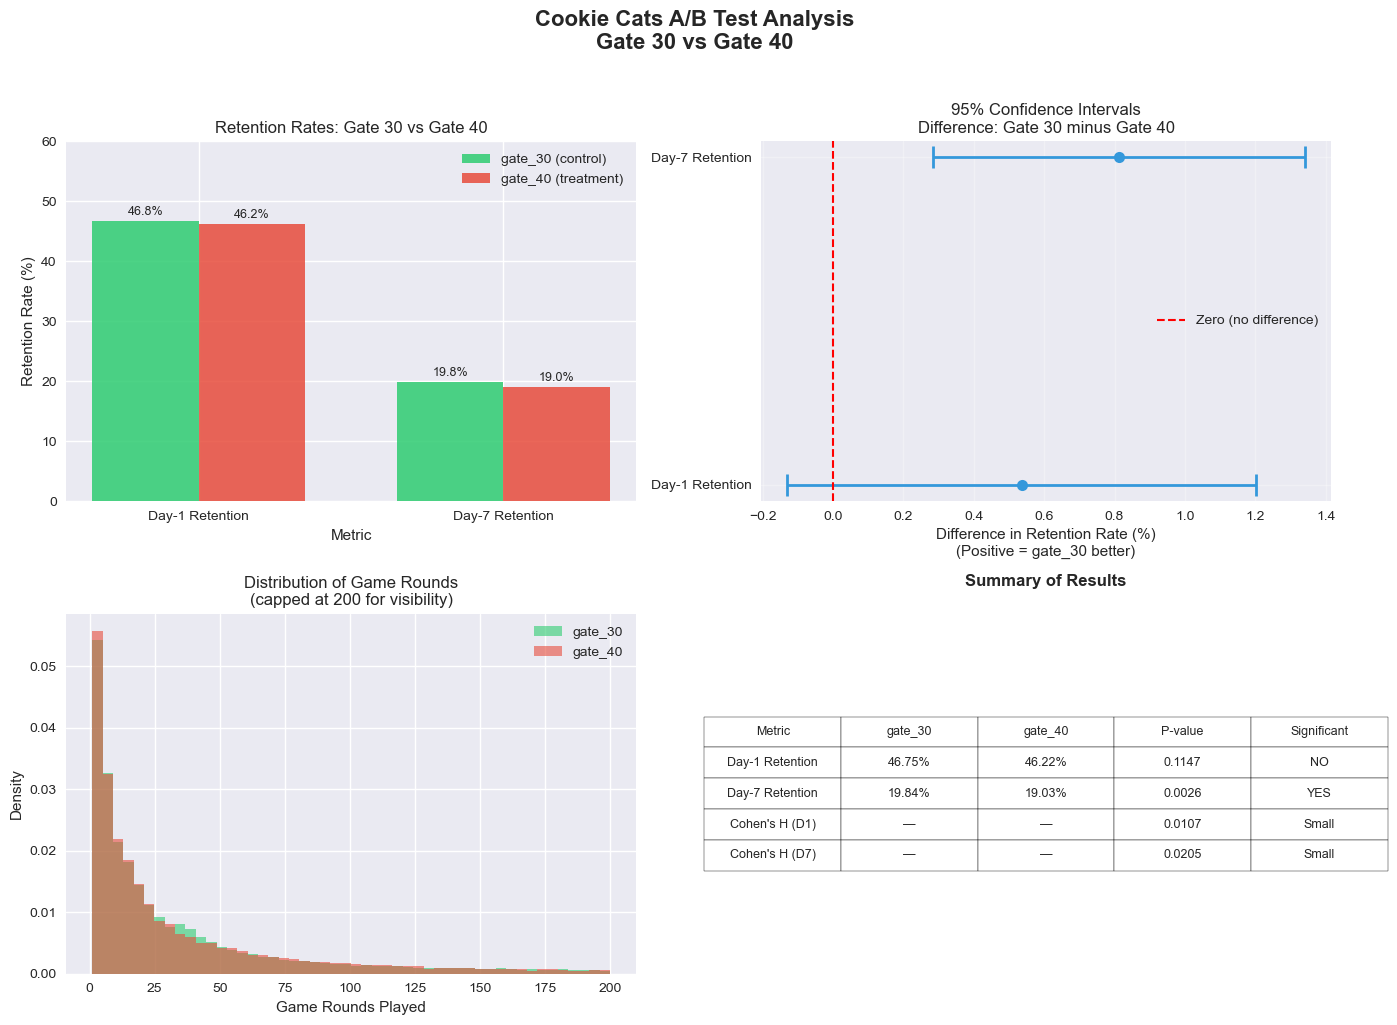

All charts saved to images folder!


In [25]:
# ================================================
# STEP 9: Visualizations (Complete)
# ================================================

plt.style.use('seaborn-v0_8')
colors = {'gate_30': '#2ecc71', 'gate_40': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cookie Cats A/B Test Analysis\nGate 30 vs Gate 40', 
             fontsize=16, fontweight='bold', y=1.02)

# ---- CHART 1: Retention Rates Bar Chart ----
ax1 = axes[0, 0]

metrics = ['Day-1 Retention', 'Day-7 Retention']
gate30_values = [p_d1_gate30 * 100, p_d7_gate30 * 100]
gate40_values = [p_d1_gate40 * 100, p_d7_gate40 * 100]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, gate30_values, width,
                label='gate_30 (control)',
                color=colors['gate_30'], alpha=0.85)
bars2 = ax1.bar(x + width/2, gate40_values, width,
                label='gate_40 (treatment)',
                color=colors['gate_40'], alpha=0.85)

ax1.set_xlabel('Metric')
ax1.set_ylabel('Retention Rate (%)')
ax1.set_title('Retention Rates: Gate 30 vs Gate 40')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim(0, 60)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# ---- CHART 2: Confidence Intervals ----
ax2 = axes[0, 1]

metrics_ci = ['Day-1 Retention', 'Day-7 Retention']
diffs = [d1_diff, d7_diff]
lowers = [d1_diff - d1_lower, d7_diff - d7_lower]
uppers = [d1_upper - d1_diff, d7_upper - d7_diff]

ax2.errorbar(diffs, metrics_ci,
             xerr=[lowers, uppers],
             fmt='o', color='#3498db',
             capsize=8, capthick=2,
             linewidth=2, markersize=8)

ax2.axvline(x=0, color='red', linestyle='--',
            linewidth=1.5, label='Zero (no difference)')
ax2.set_xlabel('Difference in Retention Rate (%)\n(Positive = gate_30 better)')
ax2.set_title('95% Confidence Intervals\nDifference: Gate 30 minus Gate 40')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ---- CHART 3: Game Rounds Distribution ----
ax3 = axes[1, 0]

df_clean_capped = df_clean[df_clean['sum_gamerounds'] <= 200]

ax3.hist(df_clean_capped[df_clean_capped['version'] == 'gate_30']['sum_gamerounds'],
         bins=50, alpha=0.6, color=colors['gate_30'],
         label='gate_30', density=True)
ax3.hist(df_clean_capped[df_clean_capped['version'] == 'gate_40']['sum_gamerounds'],
         bins=50, alpha=0.6, color=colors['gate_40'],
         label='gate_40', density=True)

ax3.set_xlabel('Game Rounds Played')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of Game Rounds\n(capped at 200 for visibility)')
ax3.legend()

# ---- CHART 4: Summary Table ----
ax4 = axes[1, 1]
ax4.axis('off')

summary_data = [
    ['Metric', 'gate_30', 'gate_40', 'P-value', 'Significant'],
    ['Day-1 Retention', '46.75%', '46.22%', '0.1147', 'NO'],
    ['Day-7 Retention', '19.84%', '19.03%', '0.0026', 'YES'],
    ["Cohen's H (D1)", '—', '—', '0.0107', 'Small'],
    ["Cohen's H (D7)", '—', '—', '0.0205', 'Small'],
]

table = ax4.table(cellText=summary_data[1:],
                  colLabels=summary_data[0],
                  loc='center',
                  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)
ax4.set_title('Summary of Results', fontweight='bold', pad=20)

# ---- SAVE AND SHOW ----
plt.tight_layout()
plt.savefig('../images/ab_test_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("All charts saved to images folder!")

In [27]:
# ================================================
# STEP 10: Business Recommendation
# ================================================

print("=" * 55)
print("BUSINESS RECOMMENDATION")
print("=" * 55)

print("""
QUESTION:
---------
Should Cookie Cats move the first gate 
from level 30 to level 40?

SHORT ANSWER:
-------------
NO — we recommend keeping the gate at level 30.

DETAILED FINDING:
-----------------
We analyzed 86,195 players split into two groups:
- gate_30 (control):  42,763 players
- gate_40 (treatment): 43,432 players

KEY RESULTS:

1. Day-1 Retention:
   - gate_30: 46.75% | gate_40: 46.22%
   - Difference: 0.53%
   - P-value: 0.1147 (NOT significant)
   - Conclusion: No proven effect on Day-1 retention
   
2. Day-7 Retention:
   - gate_30: 19.84% | gate_40: 19.03%
   - Difference: 0.81%
   - P-value: 0.0026 (SIGNIFICANT)
   - Conclusion: Moving gate HURTS 7-day retention

STATISTICAL VS BUSINESS SIGNIFICANCE:
--------------------------------------
The Day-7 difference is statistically real (p=0.0026)
but the effect size is small (Cohen's H = 0.0205).

However at Cookie Cats scale:
- 0.81% of 1,000,000 players = 8,100 players
- Each retained player = future revenue potential
- Small % × massive scale = meaningful business impact

RECOMMENDATION:
---------------
Do NOT move the gate to level 40.

Reasons:
1. Moving the gate provides NO proven Day-1 benefit
2. Moving the gate causes a PROVEN Day-7 harm
3. There is no metric where gate_40 wins
4. At scale, even small retention drops matter

LIMITATIONS:
------------
1. Effect size is small — real world impact may be 
   modest even at scale
2. Minor sample ratio mismatch (1.77%) noted
3. We measured retention only — not revenue directly
4. Long term effects beyond 7 days unknown
5. Player segments may respond differently 
   (new vs returning players)

SUGGESTED NEXT STEPS:
---------------------
1. Keep gate at level 30 (maintain current design)
2. Investigate WHY gate position affects Day-7 
   retention — player psychology research
3. Test other gate positions (level 20? level 25?)
4. Measure revenue impact directly in future tests
5. Segment analysis — do different player types 
   respond differently to gate position?
""")

print("=" * 55)
print("FINAL VERDICT: Keep gate at level 30")
print("=" * 55)

BUSINESS RECOMMENDATION

QUESTION:
---------
Should Cookie Cats move the first gate 
from level 30 to level 40?

SHORT ANSWER:
-------------
NO — we recommend keeping the gate at level 30.

DETAILED FINDING:
-----------------
We analyzed 86,195 players split into two groups:
- gate_30 (control):  42,763 players
- gate_40 (treatment): 43,432 players

KEY RESULTS:

1. Day-1 Retention:
   - gate_30: 46.75% | gate_40: 46.22%
   - Difference: 0.53%
   - P-value: 0.1147 (NOT significant)
   - Conclusion: No proven effect on Day-1 retention
   
2. Day-7 Retention:
   - gate_30: 19.84% | gate_40: 19.03%
   - Difference: 0.81%
   - P-value: 0.0026 (SIGNIFICANT)
   - Conclusion: Moving gate HURTS 7-day retention

STATISTICAL VS BUSINESS SIGNIFICANCE:
--------------------------------------
The Day-7 difference is statistically real (p=0.0026)
but the effect size is small (Cohen's H = 0.0205).

However at Cookie Cats scale:
- 0.81% of 1,000,000 players = 8,100 players
- Each retained player = futu

In [28]:
# ================================================
# STEP 11: Executive Summary
# ================================================

print("=" * 55)
print("EXECUTIVE SUMMARY")
print("Cookie Cats A/B Test — Gate Position Analysis")
print("=" * 55)

print("""
OVERVIEW:
---------
Cookie Cats tested whether moving its first in-game 
gate from level 30 to level 40 would improve player 
retention. We analyzed 86,195 players over a 7-day 
period to answer this question.

WHAT WE TESTED:
---------------
- Control group (gate at level 30): 42,763 players
- Test group (gate at level 40):    43,432 players
- We measured how many players came back 
  the next day (Day-1) and after 7 days (Day-7)

WHAT WE FOUND:
--------------
Moving the gate to level 40 made things WORSE:

- Day-1 retention: No meaningful difference
  (46.75% vs 46.22% — too small to be certain)

- Day-7 retention: Gate 30 players came back MORE
  (19.84% vs 19.03% — we are 95% confident 
  this difference is real)

WHY THIS MATTERS:
-----------------
Day-7 retention is one of our strongest indicators 
of long-term player engagement and revenue potential.

Players who return after 7 days are significantly 
more likely to make in-app purchases and become 
long-term users.

Even though the difference seems small (0.81%),
at a scale of millions of players this represents
thousands of potential paying customers.

BOTTOM LINE:
------------
Moving the gate to level 40 provides NO benefit
and causes measurable harm to long-term retention.

RECOMMENDATION:
---------------
Keep the gate at level 30.

Do not roll out the gate_40 change to all players.

WHAT WE SHOULD DO NEXT:
------------------------
1. Keep current gate position (level 30)
2. Investigate what makes level 30 the sweet spot
3. Consider testing other aspects of the gate 
   experience (wait time, price, messaging)
4. In future tests, also measure direct revenue 
   impact alongside retention

Prepared by: Fayaz Ahamed 
Dataset: Cookie Cats Mobile Game (90,189 players)
Analysis method: A/B Test with Z-test for proportions
Confidence level: 95%
""")

print("=" * 55)
print("RECOMMENDATION: Keep gate at level 30")  
print("=" * 55)

EXECUTIVE SUMMARY
Cookie Cats A/B Test — Gate Position Analysis

OVERVIEW:
---------
Cookie Cats tested whether moving its first in-game 
gate from level 30 to level 40 would improve player 
retention. We analyzed 86,195 players over a 7-day 
period to answer this question.

WHAT WE TESTED:
---------------
- Control group (gate at level 30): 42,763 players
- Test group (gate at level 40):    43,432 players
- We measured how many players came back 
  the next day (Day-1) and after 7 days (Day-7)

WHAT WE FOUND:
--------------
Moving the gate to level 40 made things WORSE:

- Day-1 retention: No meaningful difference
  (46.75% vs 46.22% — too small to be certain)

- Day-7 retention: Gate 30 players came back MORE
  (19.84% vs 19.03% — we are 95% confident 
  this difference is real)

WHY THIS MATTERS:
-----------------
Day-7 retention is one of our strongest indicators 
of long-term player engagement and revenue potential.

Players who return after 7 days are significantly 
more likely t